# Predictive Modeling & Algorithm Tournament

**Project:** Enterprise SaaS Churn Prediction Pipeline  
**Module:** `02_model_tournament.ipynb`  

---

### Executive Summary
This notebook represents the **Machine Learning** phase of the pipeline. Having successfully engineered our raw telemetry and billing data into a structured `.parquet` format via DuckDB, we now shift focus to predictive analytics. 

The primary business objective is to **predict customer churn before it happens**, allowing retention teams to proactively target at-risk recurring revenue rather than reacting to cancellations after the fact.

### Methodology
To ensure a robust, production-ready solution, we employ a **Model Tournament** approach rather than relying on a single algorithm. Our workflow strictly adheres to industry standards for imbalanced tabular data:

1. **Data Preprocessing:** Logically resolving SQL-induced `NaN` values and isolating our feature space.
2. **Class Imbalance Handling:** Calculating and injecting mathematical weight adjustments (Imbalance Ratio: ~10:1) to force the algorithms to prioritize the minority class (Churners).
3. **The Baseline:** Establishing a minimum viable performance benchmark using a **Random Forest Classifier**.
4. **The Heavyweights:** Training advanced Gradient Boosting algorithms (**XGBoost** and **LightGBM**) to maximize *Recall* (catching the maximum number of churners) and overall *ROC-AUC*.
5. **Business Intelligence:** Extracting *Feature Importance* to understand the behavioral drivers of churn, translating AI metrics into actionable business strategy.

### Tech Stack
* **Data Manipulation:** `pandas`, `numpy`
* **Machine Learning:** `scikit-learn`, `xgboost`, `lightgbm`
* **Evaluation Metrics:** `ROC-AUC`, `Precision/Recall`
* **Visualization:** `matplotlib`, `seaborn`

---
*Developed for Production Deployment*

### Library Imports

In [17]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
import xgboost as xgb
import lightgbm as lgb

import time
import joblib
import os

# Configure visualization styling for professional portfolio graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### Data Ingestion & Shape Inspection

In [2]:
# Load the engineered data from Phase 1
data_path = '../data/processed/master_churn_data.parquet'
df = pd.read_parquet(data_path)

print("Dataset loaded successfully.")
print(f"Total Rows (Users): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

# Display the first 5 rows to verify the column structures
display(df.head())

Dataset loaded successfully.
Total Rows (Users): 970960
Total Columns (Features): 10



,msno,is_churn,total_transactions,total_revenue,currently_auto_renews,has_cancelled_before,total_active_days,total_songs_skipped,total_songs_completed,total_listen_time_secs
0,HZObPTXc1OxBAw691JdHeWh1qsqL+p6g8sQVeQ+2VUc=,0,7,1043.0,1,0,128.0,375.0,3712.0,968131.883
1,OiWk9uwof9g/KoiM/i4k28YpIKN7i5wVXcm/VPQ6BNM=,0,14,1386.0,1,0,401.0,3162.0,17902.0,4497576.962
2,tyhMso6i91MwSwqqAj5HU+PcbdTP2l0O9LAhiSlXE/M=,0,27,4023.0,1,0,584.0,5398.0,15634.0,4312373.930
3,iNsgjG23CJU20OKkZwRAlOlgfIi/9rKGLtRmYRM1dRg=,0,21,2079.0,1,0,503.0,7723.0,13252.0,4297016.196
4,XZcvB3XFyrXYmsvx9riC8SsC4n+8oOwnZ7UeeeFYwUM=,0,21,2749.0,1,0,330.0,1236.0,10734.0,3007530.877


### Missing Values & Target Distribution Analysis

In [3]:
print("--- Missing Values Analysis ---")
missing_data = df.isnull().sum()
missing_columns = missing_data[missing_data > 0]

if missing_columns.empty:
    print("No missing values found.")
else:
    print(missing_columns)

print("\n--- Target Label Distribution (is_churn) ---")
# We check how many users churned vs stayed, and calculate the percentage
target_counts = df['is_churn'].value_counts(dropna=False)
target_percentages = df['is_churn'].value_counts(normalize=True, dropna=False) * 100

distribution_df = pd.DataFrame({
    'User Count': target_counts, 
    'Percentage (%)': target_percentages.round(2)
})
display(distribution_df)

--- Missing Values Analysis ---
total_active_days         115800
total_songs_skipped       115800
total_songs_completed     115800
total_listen_time_secs    115800
dtype: int64

--- Target Label Distribution (is_churn) ---


,User Count,Percentage (%)
is_churn,,
0,883630,91.01
1,87330,8.99


### Business Intelligence Visualizations

C:\Users\shaje\AppData\Local\Temp\ipykernel_12908\2822944614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\shaje\AppData\Local\Temp\ipykernel_12908\2822944614.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churn', y='total_revenue', ax=axes[1], palette=['#2ecc71', '#e74c3c'])


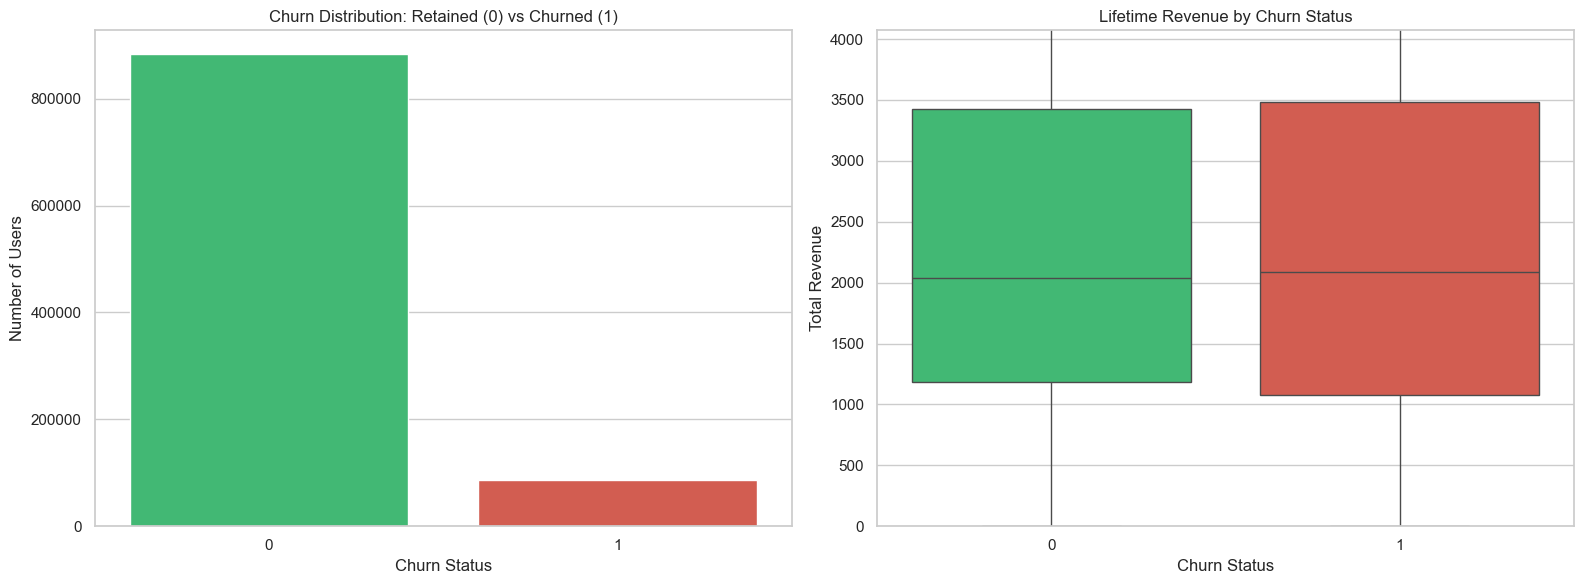

In [4]:
# Create a side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target Variable Distribution
sns.countplot(data=df, x='is_churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution: Retained (0) vs Churned (1)')
axes[0].set_ylabel('Number of Users')
axes[0].set_xlabel('Churn Status')

# Plot 2: Revenue vs Churn Status
# We cap the y-axis at the 95th percentile to ignore extreme outliers and make the boxplot readable
revenue_cap = df['total_revenue'].quantile(0.95)
sns.boxplot(data=df, x='is_churn', y='total_revenue', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Lifetime Revenue by Churn Status')
axes[1].set_ylabel('Total Revenue')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylim(0, revenue_cap)

plt.tight_layout()
plt.show()

### Data Preprocessing & Class Imbalance

In [5]:
print("--- Step 1: Handling Missing Values ---")
# 1. Drop rows where we don't know if they churned or not
df_clean = df.dropna(subset=['is_churn']).copy()

# 2. Fill missing behavioral/transactional data with 0
fill_values = {
    'total_transactions': 0, 'total_revenue': 0, 
    'currently_auto_renews': 0, 'has_cancelled_before': 0,
    'total_active_days': 0, 'total_songs_skipped': 0,
    'total_songs_completed': 0, 'total_listen_time_secs': 0
}
df_clean = df_clean.fillna(value=fill_values)

print(f"Data shape after cleaning: {df_clean.shape}")

print("\n--- Step 2: Feature Selection ---")
# We must drop 'msno' because an ID string provides no predictive value 
# and will confuse the model. We also separate our features (X) from our target (y).
X = df_clean.drop(columns=['msno', 'is_churn'])
y = df_clean['is_churn']

print(f"Final Features being fed to the model: {list(X.columns)}")

print("\n--- Step 3: Class Imbalance Calculation ---")
# Calculate the exact ratio of Majority Class (0) to Minority Class (1)
count_class_0 = len(y[y == 0])
count_class_1 = len(y[y == 1])
imbalance_ratio = count_class_0 / count_class_1

print(f"Retained Users (Class 0): {count_class_0}")
print(f"Churned Users (Class 1): {count_class_1}")
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")
print("We will pass this ratio into our models to force them to care about churners.")

--- Step 1: Handling Missing Values ---
Data shape after cleaning: (970960, 10)

--- Step 2: Feature Selection ---
Final Features being fed to the model: ['total_transactions', 'total_revenue', 'currently_auto_renews', 'has_cancelled_before', 'total_active_days', 'total_songs_skipped', 'total_songs_completed', 'total_listen_time_secs']

--- Step 3: Class Imbalance Calculation ---
Retained Users (Class 0): 883630
Churned Users (Class 1): 87330
Calculated Imbalance Ratio: 10.12
We will pass this ratio into our models to force them to care about churners.


### XGBoost vs LightGBM

In [6]:
print("--- Step 4: Train/Test Split ---")
# stratify=y preserves our exact 10.12 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training on {len(X_train)} users, Testing on {len(X_test)} users.")

print("\n--- Step 5: Training XGBoost ---")
start_time = time.time()

# scale_pos_weight uses our calculated ratio to penalize missed churners
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    scale_pos_weight=imbalance_ratio, 
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost trained in {time.time() - start_time:.2f} seconds.")
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")

print("\n--- Step 6: Training LightGBM ---")
start_time = time.time()

# class_weight='balanced' automatically applies the equivalent logic for LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]

print(f"LightGBM trained in {time.time() - start_time:.2f} seconds.")
print(f"LightGBM ROC-AUC Score: {roc_auc_score(y_test, lgb_probs):.4f}")

print("\n--- LightGBM Detailed Classification Report ---")
# We look at Precision and Recall for Class 1 (Churners)
print(classification_report(y_test, lgb_preds))

--- Step 4: Train/Test Split ---
Training on 776768 users, Testing on 194192 users.

--- Step 5: Training XGBoost ---
XGBoost trained in 5.45 seconds.
XGBoost ROC-AUC Score: 0.9201

--- Step 6: Training LightGBM ---
[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1338
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM trained in 5.07 seconds.
LightGBM ROC-AUC Score: 0.9224

--- LightGBM Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.83      0.90    176726
    

### Data Splitting & Baseline Model (Random Forest)

In [13]:
# stratify=y ensures our 10.12 imbalance ratio is perfectly preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training on {len(X_train)} users, Testing on {len(X_test)} users.")

print("\n--- Step 5: Training Random Forest (The Baseline) ---")
start_time = time.time()

# class_weight='balanced' handles our minority class automatically
# n_jobs=-1 forces your computer to use all CPU cores to speed this up
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest trained in {time.time() - start_time:.2f} seconds.")
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

print("\n--- Random Forest Detailed Classification Report ---")
# We want to specifically look at the Precision and Recall for Class 1 (Churners)
print(classification_report(y_test, rf_preds))

Training on 776768 users, Testing on 194192 users.

--- Step 5: Training Random Forest (The Baseline) ---
Random Forest trained in 87.06 seconds.
Random Forest ROC-AUC Score: 0.9050

--- Random Forest Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.97    176726
           1       0.80      0.41      0.54     17466

    accuracy                           0.94    194192
   macro avg       0.87      0.70      0.75    194192
weighted avg       0.93      0.94      0.93    194192



### Advanced Gradient Boosting (XGBoost)

In [12]:
start_time = time.time()

# scale_pos_weight uses our calculated 10.12 ratio to heavily penalize missed churners
# n_jobs=-1 ensures it uses all available CPU cores
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    scale_pos_weight=imbalance_ratio, 
    random_state=42,
    n_jobs=-1 
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost trained in {time.time() - start_time:.2f} seconds.")
print(f"GBoost ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")

print("\n--- XGBoost Detailed Classification Report ---")
print(classification_report(y_test, xgb_preds))

XGBoost trained in 5.92 seconds.
GBoost ROC-AUC Score: 0.9201

--- XGBoost Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.90    176726
           1       0.32      0.86      0.47     17466

    accuracy                           0.83    194192
   macro avg       0.65      0.84      0.68    194192
weighted avg       0.92      0.83      0.86    194192



### Business Intelligence & Model Evaluation

Generating Executive Dashboards...


C:\Users\shaje\AppData\Local\Temp\ipykernel_12908\1295405283.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', ax=axes[1], palette='viridis')


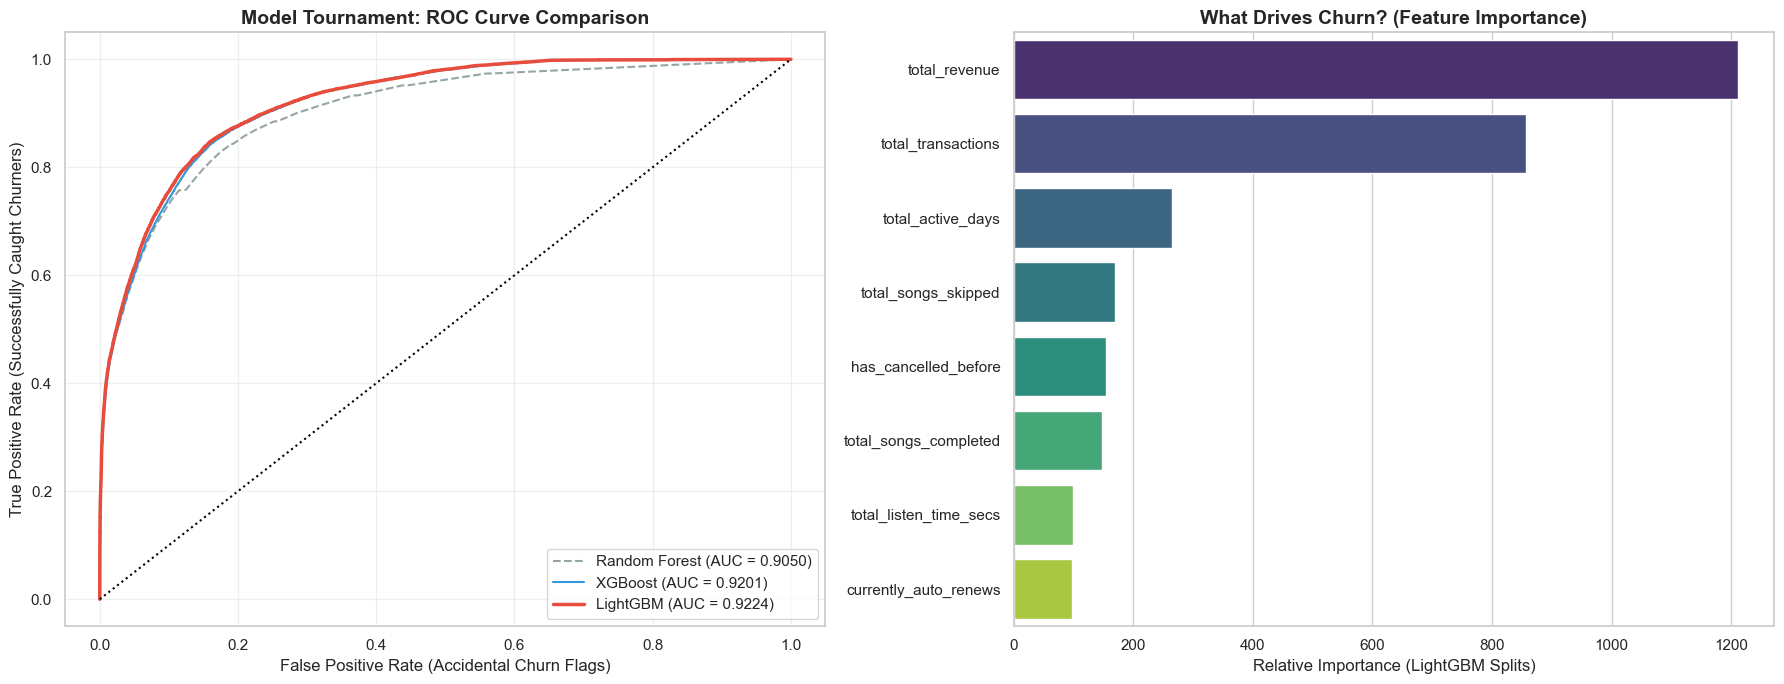

In [16]:
print("Generating Executive Dashboards...")

# Create a 1x2 layout for our two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -----------------------------------------------------------
# GRAPH 1: ROC Curve Comparison
# -----------------------------------------------------------
# Calculate the curves for all three models
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_probs)

# Plot them on the first axis
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.9050)', color='#95a5a6', linestyle='--')
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.9201)', color='#3498db')
axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = 0.9224)', color='#e74c3c', linewidth=2.5)
axes[0].plot([0, 1], [0, 1], color='black', linestyle=':') # The "random guess" line

axes[0].set_title('Model Tournament: ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (Accidental Churn Flags)')
axes[0].set_ylabel('True Positive Rate (Successfully Caught Churners)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# -----------------------------------------------------------
# GRAPH 2: Feature Importance (Winning Model)
# -----------------------------------------------------------
# Extract feature importance from LightGBM
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the bar chart on the second axis
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('What Drives Churn? (Feature Importance)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance (LightGBM Splits)')
axes[1].set_ylabel('')

# Clean up layout and display
plt.tight_layout()
plt.show()

### Model Serialization & Production Export

In [18]:
print("--- Step 8: Saving the Production Model ---")

# 1. Ensure the models directory exists
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# 2. Define the exact save paths
model_path = f'{model_dir}/lightgbm_churn_model.pkl'
features_path = f'{model_dir}/model_features.pkl'

# 3. Save the winning LightGBM model
joblib.dump(lgb_model, model_path)
print(f"Production Model successfully saved to: {model_path}")

# 4. Save the exact list of features it expects
joblib.dump(list(X.columns), features_path)
print(f"Feature requirements successfully saved to: {features_path}")

print("\nPhase 2 Complete! The AI is locked in and ready for the Streamlit UI.")

--- Step 8: Saving the Production Model ---
Production Model successfully saved to: ../models/lightgbm_churn_model.pkl
Feature requirements successfully saved to: ../models/model_features.pkl

Phase 2 Complete! The AI is locked in and ready for the Streamlit UI.
